In [8]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, json, gc, math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.Plotter.index import Plotter
from Network.index import ModelNetwork
from utils.index import *

In [9]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.7.1+cu128
True
NVIDIA GeForce RTX 5070


# HISTÓRICO DE TREINAMENTO

In [10]:
BACKUP = r'../Model/Backup'

In [11]:
df = []

for backup in os.listdir(BACKUP):
    path = os.path.join(BACKUP, f'{backup}/info.json')

    with open(path, 'r', encoding='utf-8') as file:
        file = json.loads(file.read())

    info = {}
    # AS SEÇÕES (trainer, processing, division, model, iou) VIRAM COLUNAS; CAMPO SOLTO COMO O title ENTRA COM O PRÓPRIO NOME
    for key, value in file.items():
        if key != 'marlim_iou':
            info.update(value if isinstance(value, dict) else {key: value})

    # O marlim_iou DO 3 - Predict E POR CLASSE COMO O iou DO TESTE: NA TABELA ENTRA SO A MEDIA, SEM SOBRESCREVER O TESTE
    info['marlim_iou'] = file.get('marlim_iou', {}).get('mean')

    if not info.get('dataset'):
        info['dataset'] = 'facies'

    # MODELOS DE ANTES DO EMA E DOS TRIALS: TREINADOS SEM EMA, UMA RODADA SO
    info.setdefault('ema', False)
    info.setdefault('trial', 0)
    info['id'] = int(info.get('path').split('_')[-1])
    df.append(info)


df = pd.DataFrame(df).sort_values(by='id')
df.head()

,path,loss,scheduler,epochs,batch_size,economy,ema,trial,val_iou,test_iou,network,dataset,img_size,step,multiclass,lr,dropout,num_filters,n_trials,n_images,classes,channels,deep_supervision,0,1,2,3,4,5,marlim_iou,id
2,model_1,dice_focal,plateau,200,2,True,True,0,0.940578,0.938275,dbrnet,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.985320,0.887350,0.910654,0.932812,0.917620,0.995911,0.963480,1
1,model_2,dice_focal,plateau,200,2,True,True,0,0.940243,0.935720,resaceunet_grva,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.984192,0.882267,0.906184,0.930590,0.915043,0.996017,0.963733,2
4,model_3,dice_focal,plateau,200,2,True,True,0,0.923609,0.912866,macnn,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.977048,0.842844,0.877655,0.905395,0.880199,0.994155,0.948210,3
3,model_4,dice_focal,plateau,200,2,True,True,0,0.928816,0.921746,fault_seg_net,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.981653,0.857184,0.883415,0.914307,0.898815,0.995125,0.952659,4
0,model_5,dice_focal,plateau,200,2,True,True,0,0.925152,0.912039,nru_net,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.976965,0.838954,0.874010,0.905425,0.881993,0.994902,0.944973,5


### Filtrando o Alvo

In [12]:
df['total_images'] = [n_images.get('total') for n_images in df.n_images.values]
df.head(2)

,path,loss,scheduler,epochs,batch_size,economy,ema,trial,val_iou,test_iou,network,dataset,img_size,step,multiclass,lr,dropout,num_filters,n_trials,n_images,classes,channels,deep_supervision,0,1,2,3,4,5,marlim_iou,id,total_images
2,model_1,dice_focal,plateau,200,2,True,True,0,0.940578,0.938275,dbrnet,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.985320,0.887350,0.910654,0.932812,0.917620,0.995911,0.963480,1,7074
1,model_2,dice_focal,plateau,200,2,True,True,0,0.940243,0.935720,resaceunet_grva,facies,"[4, 256, 256]",3,True,0.0001,0.05,32,1,"{'total': 7074, 'train': 5658, 'val': 708, 'te...",6,1,False,0.984192,0.882267,0.906184,0.930590,0.915043,0.996017,0.963733,2,7074


# ANÁLISE DE VARIAÇÕES

alvo: network | fixos: {'dataset': 'facies', 'loss': 'dice_focal', 'lr': 0.0001, 'dropout': 0.05, 'img_size': '[4, 256, 256]'}


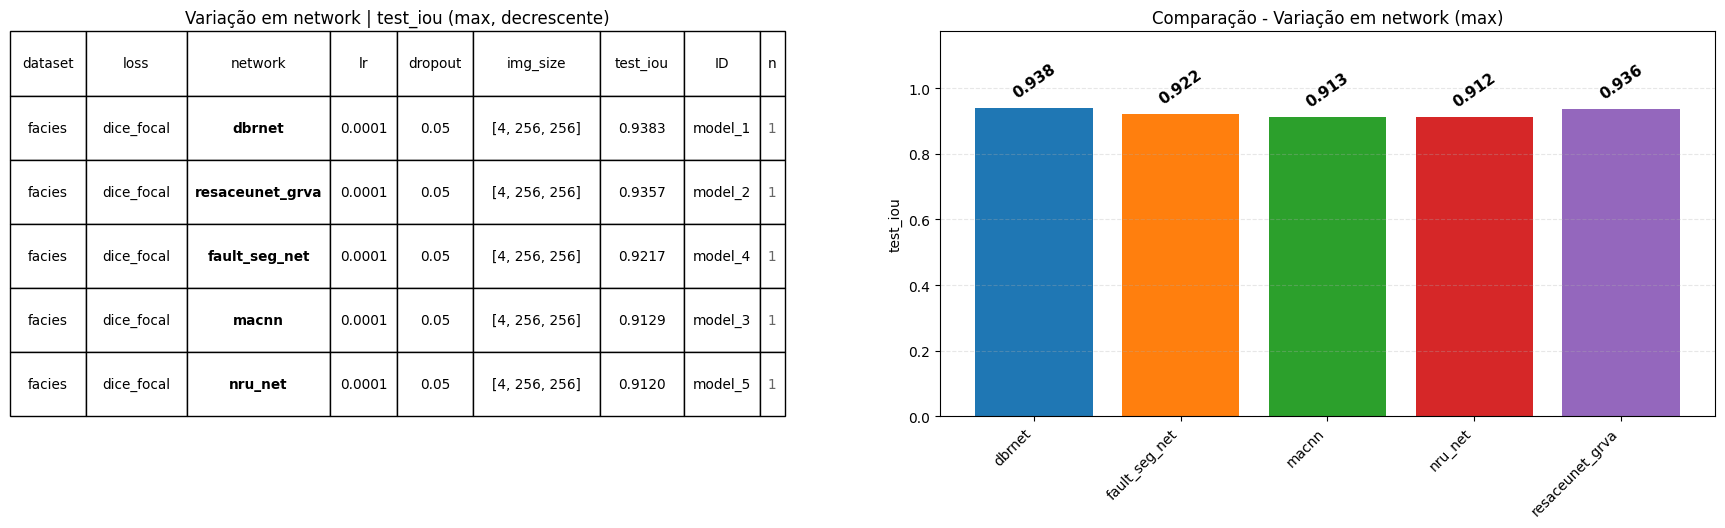

In [14]:
class VariationAnalysis:
    MODES       = ('min', 'max', 'mean', 'median')
    COUNT       = 'n'
    ID          = 'ID'
    MAX_STR_LEN = 24          # SÓ CORTA VALORES EXTREMOS, O RESTO CABE REDUZINDO A FONTE
    PADDING     = 2           # CARACTERES DE FOLGA POR COLUNA
    CHAR_WIDTH  = 0.62        # LARGURA DE UM CARACTERE EM FRAÇÃO DA FONTE
    ROW_HEIGHT  = 0.55        # FRAÇÃO DA LINHA OCUPADA PELA FONTE
    FONT        = (6, 14)
    FIG_WIDTH   = 22
    ROW_INCHES  = 0.5
    HEIGHT      = (5, 20)
    MARGIN      = 0.25        # FOLGA ACIMA DAS BARRAS PARA OS RÓTULOS

    def __init__(self, df, variations, id=None, metric='test_mre_mm', mode='mean', asc=True):
        self.df         = df
        self.variations = variations
        self.id         = id
        self.metric     = metric
        self.mode       = mode
        self.asc        = asc
        self.showStd    = mode == 'mean'    # DESVIO SÓ FAZ SENTIDO COMO BARRA EM TORNO DA MÉDIA

    def update(self):
        df = self.df.copy()
        df[self.metric] = pd.to_numeric(df[self.metric], errors='coerce')
        df = df.dropna(subset=[self.metric]).reset_index(drop=True)

        for col in self.variations:
            numeric = pd.to_numeric(df[col], errors='coerce')
            df[col] = numeric if numeric.notna().sum() == df[col].notna().sum() else df[col].astype(str)

        if self.id:
            df[self.id] = df[self.id].astype(str).map(os.path.normpath)

        self.df = df

    # MIN/MAX: PASTA DO MODELO ESCOLHIDO | MEAN/MEDIAN: PASTA GERAL EM COMUM DO GRUPO
    def identify(self, df, groups):
        if self.mode in ('min', 'max'):
            paths = df.loc[groups.agg(f'idx{self.mode}').values, self.id]
            return paths.map(os.path.basename).values

        common = lambda paths: os.path.basename(os.path.commonpath(list(paths))) or '-'
        return df.groupby(self.variations, dropna=False)[self.id].agg(common).values

    def aggregate(self, df):
        groups = df.groupby(self.variations, dropna=False)[self.metric]
        agg    = groups.agg([self.mode, 'std', 'size']).rename(columns={self.mode: self.metric, 'size': self.COUNT}).reset_index()

        if self.id:
            agg.insert(agg.columns.get_loc(self.metric) + 1, self.ID, self.identify(df, groups))

        return agg.sort_values(self.metric, ascending=self.asc, kind='stable')

    # UMA FIGURA POR HIPERPARÂMETRO PARA CADA COMBINAÇÃO FIXA DOS OUTROS
    def plot(self):
        for var in self.variations:
            fixed  = [col for col in self.variations if col != var]
            groups = self.df.groupby(fixed, dropna=False) if fixed else [(None, self.df)]

            for _, group in groups:
                if group[var].nunique(dropna=False) <= 1:
                    continue

                print(f'alvo: {var} | fixos: {group.iloc[0][fixed].to_dict()}')
                self.showComparison(self.aggregate(group), var)

    # TABELA À ESQUERDA E BARRAS (COM DESVIO SE FOR MÉDIA) À DIREITA
    def showComparison(self, table, var):
        order  = 'crescente' if self.asc else 'decrescente'
        chart  = table.sort_values(var, kind='stable')
        values = chart[self.metric]
        err    = chart['std'].fillna(0) if self.showStd else 0    # LIMITES INCLUEM AS BARRAS DE ERRO
        low    = min(0, (values - err).min())
        high   = max(0, (values + err).max())
        pad    = self.MARGIN * ((high - low) or 1)
        limits = (low - pad * (low < 0), high + pad)
        height = len(table) * self.ROW_INCHES + 2    # TÍTULO E CABEÇALHO
        extra  = {'stds': chart['std'].tolist()} if self.showStd else {}

        plt.figure(figsize=(self.FIG_WIDTH, min(max(height, self.HEIGHT[0]), self.HEIGHT[1])))
        plt.subplot(1, 2, 1)
        self.showTable(table.drop(columns='std'), var, f'Variação em {var} | {self.metric} ({self.mode}, {order})')

        plt.subplot(1, 2, 2)
        Plotter(dict(zip(chart[var].astype(str), values)), limits=limits, title=f'Comparação - Variação em {var} ({self.mode})', **extra)
        plt.ylabel(self.metric)
        plt.show()

    def showTable(self, table, boldCol, title):
        cells = table.copy()
        cells[self.metric] = cells[self.metric].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
        cells = cells.astype(str)

        for col in cells.columns.drop([self.metric, self.COUNT]):
            cells[col] = cells[col].where(cells[col].str.len() <= self.MAX_STR_LEN, cells[col].str.slice(0, self.MAX_STR_LEN - 1) + '…')

        ax         = plt.gca()
        box        = ax.get_position()
        figW, figH = ax.figure.get_size_inches()
        widths     = [max(len(col), cells[col].str.len().max()) + self.PADDING for col in cells.columns]
        fitW       = figW * box.width * 72 / (sum(widths) * self.CHAR_WIDTH)    # 72 PT POR POLEGADA
        fitH       = figH * box.height * 72 / (len(cells) + 1) * self.ROW_HEIGHT
        styles     = {boldCol: {'fontweight': 'bold'}, self.COUNT: {'color': '0.4'}}

        ax.axis('off')
        grid = ax.table(cellText=cells.values, colLabels=cells.columns, colWidths=[width / sum(widths) for width in widths], cellLoc='center', bbox=[0, 0, 1, 1])
        grid.auto_set_font_size(False)
        grid.set_fontsize(max(self.FONT[0], min(self.FONT[1], fitW, fitH)))

        for (row, col), cell in grid.get_celld().items():
            if row > 0 and cells.columns[col] in styles:
                cell.set_text_props(**styles[cells.columns[col]])

        plt.title(title)


variations = ['dataset', 'loss', 'network', 'lr', 'dropout', 'img_size']
analysis   = VariationAnalysis(df, variations, id='path', metric='test_iou', mode='max', asc=False)
analysis.update()
analysis.plot()